# August 2026 canonical forecast — LOL 165K + headwind −1,295,000 (anchor 2026-07-28)

**Not yet a delivered forecast.** Two of the three overlay curves are still stale carry-forwards from
July. See the caveats cell at the bottom before quoting anything.

Ported from `data-official/2026-07/july_canonical_v2026-06-29.ipynb`.

## What has changed since July

**1. The seam moved 2026-07-06 → 2026-07-28** (training through 2026-07-27, the freshest day both
platforms have complete). Both platforms share the seam, as in July.

**2. The launch-on-login (`l`) ceiling was raised 125,000 → 165,000 DAU/day** (task-owner decision,
rebuilt 2026-07-29). New curve shape:

| span | value |
|---|---|
| ≤ 2026-05-07 | 0 (pre-rollout) |
| 2026-05-08 → 2026-06-23 | **measured** — FF152-excluded, interpolated 7d trailing MA of the holdback excess; 130,296 at the last clean day |
| 2026-06-24 → 2026-07-05 | **extrapolated** — linear ramp at 2,714/day (the ~19,000/wk rise recorded at the cutoff) |
| 2026-07-06 → 2027-12-31 | flat at **165,000** |

Versus July's flat-125K curve that is **+40,000/day at every forecast date**, and **+30,145/day on
average across the 39 affected training days** (2026-06-19 → 2026-07-27). `l` is a *bidirectional*
overlay — subtracted from `modern_windows` training rows before mozaic, added back after — so the Dec-15
effect need not equal +40,000. Measured, it came in at **+41,081**: essentially pass-through. See the
ledger in `[desktop-dec15]`.

**3. The Win10 headwind (`h`) desktop anchor was attenuated +50,000**, from July's −1,345,000 to
**−1,295,000** at the Dec-15 anchor. Rationale: Prophet has learned more of the Win10 decline from the
five extra weeks of data, so less of it needs carrying exogenously. Same direction as July's own +25,000
add-back (−1,370,000 → −1,345,000) and consistent with June's conclusion that `adj-h` should shrink as
the headwind shows up in the data. **Mobile unchanged at −27,162.**

`h` is a **display-layer** adjustment applied to the 28-day MA in `[compute-series]`, not baked into the
forecast parquet — so this change required no model re-run. The desktop parquet here is the same one
built for the LOL-165K rebuild.

## What is still held fixed from July

| Component | Value | Note |
|---|---|---|
| Desktop params | `cps=0.08983, cpr=0.65, ncp=25, recent=13, threshold=−0.032` | July's locked param search |
| Mobile params | `cps=0.035, cpr=0.75, ncp=25, recent=13, threshold=−0.055` | July's `grad_moderate` grid result |
| MozillaOnline (`o`) | Brad's official CN migration curve | **STALE** — byte-identical carry-forward |
| Marketing lift (`m`) | June-anchored Fenix paid curve | **STALE** — byte-identical carry-forward |

Mobile is untouched by this iteration — `l` is desktop-only, so the mobile forecast is the same run as
the 125K baseline. Any mobile movement you see versus July is the data refresh alone.

`seasonality_prior_scale` / `seasonality_regime` remain at package defaults (0.00825 desktop / 0.1
mobile, regime `auto`), which reproduce the values hardcoded at the time of July's build — so the three
mozaic-package commits landed since July are behaviour-neutral here.

## Reference points

| build | Desktop Dec-15 28d-MA |
|---|--:|
| July delivered (125K LOL, hw −1,345,000, 07-06 anchor) | 48,585,483 |
| August baseline (125K LOL, hw −1,345,000, 07-28 anchor) | 48,520,714 |
| **this build (165K LOL, hw −1,295,000, 07-28 anchor)** | see `[desktop-dec15]` |

`[desktop-dec15]` decomposes the gap between the first and last rows into its three parts — data
refresh, LOL cap, headwind attenuation — and asserts the ledger closes against the measured value, so a
stale reference constant cannot pass silently.


In [1]:
# [setup]
import os
import subprocess
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from google.cloud import bigquery

# Anchor execution at git root so relative paths work regardless of notebook location.
os.chdir(subprocess.run(['git', 'rev-parse', '--show-toplevel'],
                        capture_output=True, text=True).stdout.strip())

# --- File paths ---
# AUGUST cycle, LOL-165K iteration. One forecast per platform, both anchored to forecast_start
# 2026-07-28 (trained through 2026-07-27, the freshest day both legacy_desktop and glean_mobile have
# complete). Iran is included like any other country -- queried natively, with the 2026-03-01 ->
# 05-25 shutdown gap covered by mozaic's built-in counterfactual fill. Not a separate series.
#
# Both models carry JULY'S LOCKED PARAMETERS unchanged. Overlay state differs per code:
#   l (launch-on-login) -- REBUILT 2026-07-29, ceiling raised 125,000 -> 165,000 DAU/day. Desktop only.
#   o (MozillaOnline)   -- byte-identical carry-forward from July. STALE.
#   m (marketing lift)  -- byte-identical carry-forward from July. STALE. Mobile only.
#   h (Win10 headwind)  -- desktop anchor ATTENUATED +50,000 to -1,295,000 (July: -1,345,000); mobile
#                          unchanged at -27,162. Display layer, so no model re-run was needed.
# The desktop parquet below therefore differs from the 125K baseline; the mobile parquet is the SAME
# run (l is desktop-only). See the intro cell.
DESKTOP_FORECAST_PATH = (
    "data-official/2026-08/desktop_baseline_2026-07-28/"
    "cps0.08983_thresh032_recent13_cpr0.65_ncp25_clip0.6_sps0.00825/"
    "mozaic_daily_forecast.2026-07-28.ld-D.adj-lo.parquet"
)
MOBILE_FORECAST_PATH = (
    "data-official/2026-08/mobile_baseline_2026-07-28/"
    "cps0.035_thresh055_recent13_cpr0.75_ncp25_clip0.6_sps0.1/"
    "mozaic_daily_forecast.2026-07-28.gm-D.adj-m.parquet"
)

# Prior (N-1) = JULY's DELIVERED forecast. Unlike June->July, no reconstruction hack is needed here:
# July's MozillaOnline tailwind is the measured `o` overlay baked into the parquet, not a flat +500K
# step bolted on at the display layer. So the prior line is just (parquet + July's own headwind).
PREV_FORECAST_DESKTOP_PATH = (
    "data-official/2026-07/desktop_locked/"
    "mozaic_daily_forecast.2026-07-06.ld-D.adj-lo.parquet"
)
PREV_FORECAST_MOBILE_PATH = (
    "data-official/2026-07/mobile_refresh_2026-07-06/"
    "cps0.035_thresh055_recent13_cpr0.75_ncp25_clip0.6/"
    "mozaic_daily_forecast.2026-07-06.gm-D.adj-m.parquet"
)

# Display-layer adjustments (the Win10 headwind `h`): linear ramp from 2026-04-01 reaching
# desktop -1,295,000 / mobile -27,162 at the 2026-12-15 anchor.
#
# The prior line reads July's OWN spec dir, which still holds -1,345,000. Keeping the two separate is
# exactly what makes an anchor change safe: editing August's spec cannot retroactively alter the July
# comparison curve, and [desktop-dec15] asserts July still reproduces its delivered value.
ADJUSTMENTS_DIR = "data-official/2026-08/adjustments"
PREV_ADJUSTMENTS_DIR = "data-official/2026-07/adjustments"

PLOTS_DIR = "data-official/2026-08/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# --- Date constants ---
DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
FORECAST_START = pd.Timestamp("2026-07-28")          # desktop seam
MOBILE_FORECAST_START = pd.Timestamp("2026-07-28")   # mobile seam (same -- consistent, as in July)
PREV_FORECAST_START = pd.Timestamp("2026-07-06")     # July's seam
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")

# BQ query lookback -- need 28 days before DISPLAY_START for the trailing MA.
BQ_START = "2025-12-04"

print(f"cwd: {os.getcwd()}")
print(f"seam: {FORECAST_START.date()} (both platforms) | prior seam: {PREV_FORECAST_START.date()}")


cwd: /Users/brendanwells/work/mozaic-daily
seam: 2026-07-28 (both platforms) | prior seam: 2026-07-06


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# [helpers]
import sys

sys.path.insert(0, "src")

# Reuse the variance-matched display_ma (seam-smoothed forecast MA) from June's canonical exporter
# (generic in forecast_start) so forecast curves match the shape used in the June and July cycles.
# Actuals use the plain daily_to_28ma below. See research/ma-seam-turbulence/ for the diagnosis.
# NOTE: this is still a 2026-06 dependency -- flagged for the September roll-forward, when August
# should own its own copy of the exporter (see data-official/_index.md).
sys.path.insert(0, "data-official/2026-06")
from export_canonical_curves import display_ma  # noqa: E402

# Loading through load_forecast (not bare pd.read_parquet) enforces the artifact contract: the
# filename state marker must exist, a sidecar .meta.json must exist, and the codes in the two must
# agree. require_state additionally pins WHICH adjustments we expect, so a mislabelled or
# wrong-overlay parquet fails loudly here instead of silently producing a wrong headline number.
from mozaic_daily.adjustments import load_forecast  # noqa: E402


def render_adjustment(spec, date_index):
    """Convert a single adjustment spec to net DAU Series for desktop and mobile."""
    idx = pd.DatetimeIndex(date_index)
    desktop = pd.Series(0.0, index=idx)
    mobile = pd.Series(0.0, index=idx)

    if spec["type"] == "linear_ramp":
        start = pd.Timestamp(spec["start_date"])
        anchor = pd.Timestamp(spec["anchor_date"])
        total_days = (anchor - start).days
        elapsed = np.maximum(0, (idx - start).days)
        desktop[:] = spec.get("desktop_dau", 0) * elapsed / total_days
        mobile[:] = spec.get("mobile_dau", 0) * elapsed / total_days

    elif spec["type"] == "step":
        start = pd.Timestamp(spec["start_date"])
        end = pd.Timestamp(spec["end_date"]) if "end_date" in spec else idx[-1]
        mask = (idx >= start) & (idx <= end)
        desktop[mask] = spec.get("desktop_dau", 0)
        mobile[mask] = spec.get("mobile_dau", 0)

    elif spec["type"] == "daily_series":
        for date_str, values in spec["series"].items():
            date = pd.Timestamp(date_str)
            if date in idx:
                loc = idx.get_loc(date)
                desktop.iloc[loc] = values.get("desktop_dau", 0)
                mobile.iloc[loc] = values.get("mobile_dau", 0)

    return {"desktop": desktop, "mobile": mobile}


def load_adjustments(adjustments_dir, date_index):
    """Sum all adjustment components in a directory into net desktop/mobile DAU series."""
    idx = pd.DatetimeIndex(date_index)
    desktop_total = pd.Series(0.0, index=idx)
    mobile_total = pd.Series(0.0, index=idx)
    found = sorted(glob.glob(f"{adjustments_dir}/*.json"))
    if not found:
        raise FileNotFoundError(
            f"No adjustment specs in {adjustments_dir}. The August baseline is defined to carry "
            f"July's Win10 headwind; an empty dir would silently publish a pre-headwind number."
        )
    for path in found:
        with open(path) as f:
            spec = json.load(f)
        rendered = render_adjustment(spec, idx)
        desktop_total += rendered["desktop"]
        mobile_total += rendered["mobile"]
    return {"desktop": desktop_total, "mobile": mobile_total}


def apply_net_adjustment(ma_series, net_adjustments, platform, forecast_start=None):
    """Apply net adjustment to a 28-day MA series, starting at forecast_start.

    The adjustment applies only from the seam forward -- history is actuals and must not be moved.
    Callers comparing an N-1 forecast MUST pass that forecast's own seam (PREV_FORECAST_START),
    not the current one, or the prior curve gets adjusted over a stretch that was already actual.
    """
    if forecast_start is None:
        forecast_start = FORECAST_START
    result = ma_series.copy()
    forecast_mask = result.index >= forecast_start
    adj = net_adjustments[platform].reindex(result.index, fill_value=0.0)
    result[forecast_mask] += adj[forecast_mask]
    return result


def load_all_level_dau(path, data_source, segment_filter, app_filter, *, require_state):
    """Load a validated forecast parquet, return World(ALL) daily DAU with data_type."""
    df, meta = load_forecast(path, require_state=require_state)
    mask = (
        (df["country"] == "ALL")
        & (df["segment"] == segment_filter)
        & (df["data_source"] == data_source)
        & (df["app_name"] == app_filter)
    )
    result = df.loc[mask, ["target_date", "dau", "data_type"]].copy()
    result["target_date"] = pd.to_datetime(result["target_date"])
    return result.sort_values("target_date").reset_index(drop=True), meta


def daily_to_28ma(dates, values):
    """Compute 28-day trailing moving average. Returns a date-indexed Series."""
    s = pd.Series(values.values, index=pd.to_datetime(dates.values))
    return s.sort_index().rolling(28).mean()


def millions_formatter(x, pos):
    # Two decimals so adjacent ~0.5M-spaced ticks stay distinct (e.g. 16.50M vs 17.00M),
    # rather than collapsing to identical whole-million labels (16M / 16M / 17M).
    return f"{x / 1e6:.2f}M"


def clip_display(s):
    """Filter a date-indexed series to the display window."""
    return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)].dropna()


def clip_forecast_only(s, forecast_start=None):
    """Filter to the forecast portion only, within the display window."""
    if forecast_start is None:
        forecast_start = FORECAST_START
    return s[(s.index >= forecast_start) & (s.index <= DISPLAY_END)].dropna()


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# [load-parquets]
# Both platforms at the 2026-07-28 seam (trained through 2026-07-27). require_state pins the expected
# overlays: desktop must be adj-lo (launch-on-login + MozillaOnline), mobile must be adj-m (marketing
# lift). If a run silently failed to match its spec date it would have emitted .raw. and this fails.
desktop_raw, desktop_meta = load_all_level_dau(
    DESKTOP_FORECAST_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop", require_state=["l", "o"])
mobile_raw, mobile_meta = load_all_level_dau(
    MOBILE_FORECAST_PATH, "glean_mobile", "{}", "ALL MOBILE", require_state=["m"])

for label, df, seam in [("Desktop", desktop_raw, FORECAST_START),
                        ("Mobile", mobile_raw, MOBILE_FORECAST_START)]:
    last_train = df.loc[df["data_type"] == "training", "target_date"].max()
    print(f"{label}: {len(df)} rows, {df['target_date'].min().date()} to "
          f"{df['target_date'].max().date()} | seam {seam.date()} | last training {last_train.date()}")

# Confirm the runs used July's locked parameters -- this is the whole premise of the baseline.
EXPECTED_DESKTOP_CONFIG = {
    "prophet_changepoint_prior_scale": 0.08983, "prophet_changepoint_range": 0.65,
    "prophet_n_changepoints": 25, "prophet_recent_weeks": 13, "holiday_threshold": -0.032,
    "holiday_max_radius": 5, "holiday_min_radius": 3, "holiday_effect_floor": -0.6,
}
EXPECTED_MOBILE_CONFIG = {
    "prophet_changepoint_prior_scale": 0.035, "prophet_changepoint_range": 0.75,
    "prophet_n_changepoints": 25, "prophet_recent_weeks": 13, "holiday_threshold": -0.055,
    "holiday_max_radius": 5, "holiday_min_radius": 3, "holiday_effect_floor": -0.6,
}
for label, meta, expected in [("desktop", desktop_meta, EXPECTED_DESKTOP_CONFIG),
                              ("mobile", mobile_meta, EXPECTED_MOBILE_CONFIG)]:
    actual = meta["model_config"]
    drift = {k: (v, actual.get(k)) for k, v in expected.items() if actual.get(k) != v}
    assert not drift, f"{label} config drifted from July's lock: {drift}"
    print(f"{label} config matches July's lock ({len(expected)} params checked)")

print("\nAdjustments recorded in sidecars:")
for label, meta in [("desktop", desktop_meta), ("mobile", mobile_meta)]:
    for adj in meta.get("adjustments_applied", []):
        print(f"  {label:8s} {adj['code']}  {adj.get('name','')}  spec={adj.get('spec_file','')}")


Desktop: 2922 rows, 2020-01-01 to 2027-12-31 | seam 2026-07-28 | last training 2026-07-27
Mobile: 2557 rows, 2020-12-31 to 2027-12-31 | seam 2026-07-28 | last training 2026-07-27
desktop config matches July's lock (8 params checked)
mobile config matches July's lock (8 params checked)

Adjustments recorded in sidecars:
  desktop  l  launch_on_login  spec=/Users/brendanwells/work/mozaic-daily/data-official/2026-08/launch_on_login/lol.json
  desktop  o  mozillaonline_migration  spec=/Users/brendanwells/work/mozaic-daily/data-official/2026-08/mozillaonline/mozillaonline.json
  mobile   m  marketing_lift  spec=data-official/2026-08/marketing/marketing.json


In [4]:
# [load-prev-forecast]
# Prior (N-1) = July's DELIVERED forecast, loaded with the same state validation. July's desktop
# already carries `o` as a measured overlay inside the parquet, so -- unlike the June->July notebook
# -- there is NO flat-tailwind reconstruction step needed to reproduce the delivered curve.
prev_desktop_raw, prev_desktop_meta = load_all_level_dau(
    PREV_FORECAST_DESKTOP_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop", require_state=["l", "o"])
prev_mobile_raw, prev_mobile_meta = load_all_level_dau(
    PREV_FORECAST_MOBILE_PATH, "glean_mobile", "{}", "ALL MOBILE", require_state=["m"])
print(f"Prior desktop: {len(prev_desktop_raw)} rows | mobile: {len(prev_mobile_raw)} rows")
print(f"Prior seam: {PREV_FORECAST_START.date()} "
      f"(desktop last training {prev_desktop_raw.loc[prev_desktop_raw.data_type == 'training', 'target_date'].max().date()})")


Prior desktop: 2922 rows | mobile: 2557 rows
Prior seam: 2026-07-06 (desktop last training 2026-07-05)


In [5]:
# [bq-actuals]
# Actuals cutoff = CURRENT_DATE("America/Los_Angeles") - 2 because Glean mobile's most-recent landed
# day can be partial (one ~500k DAU point poisons the trailing MA28 endpoint by ~1M). The LA-time
# clamp matters: plain CURRENT_DATE() returns UTC, so after ~5pm PDT it bumps to tomorrow and -2
# lands ON the still-partial day. All countries (Iran included). Legacy telemetry for desktop.
import time

client = bigquery.Client(project="moz-fx-data-bq-data-science")

queries = {
    "desktop": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
        WHERE app_name = "Firefox Desktop"
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
        GROUP BY submission_date ORDER BY 1
    """,
    "mobile": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
        WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS")
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
        GROUP BY submission_date ORDER BY 1
    """,
}

bq_actuals = {}
t0 = time.time()
for i, (name, sql) in enumerate(queries.items(), 1):
    sys.stdout.write(f"[{i}/{len(queries)}] {name}...")
    sys.stdout.flush()
    df = client.query(sql).to_dataframe()
    df["date"] = pd.to_datetime(df["date"])
    bq_actuals[name] = df
    sys.stdout.write(f" {len(df)} rows, through {df['date'].max().date()} "
                     f"({time.time() - t0:.1f}s elapsed)\n")
    sys.stdout.flush()

print("Done.")


[1/2] desktop...

 236 rows, through 2026-07-27 (9.3s elapsed)


[2/2] mobile...

 236 rows, through 2026-07-27 (14.3s elapsed)


Done.


In [6]:
# [compute-series]
# 28-day MAs. Forecast curves use the variance-matched display_ma (seam-smoothed); actuals use the
# plain daily_to_28ma. One forecast per platform (Iran included). Both platforms share the seam at
# FORECAST_START = 2026-07-28 (trained through 2026-07-27).
desktop_ma_raw = display_ma(desktop_raw["target_date"], desktop_raw["dau"], FORECAST_START)
mobile_ma_raw = display_ma(mobile_raw["target_date"], mobile_raw["dau"], MOBILE_FORECAST_START)

# The Win10 headwind (adj-h) IS applied: a linear ramp from 2026-04-01 reaching desktop -1,295,000 /
# mobile -27,162 at the 2026-12-15 anchor. The DESKTOP anchor was attenuated +50,000 from July's
# -1,345,000 on 2026-07-29 -- Prophet has learned more of the Win10 decline from the five extra weeks of
# data, so less of it needs to be carried exogenously. Same direction as July's own +25,000 add-back
# (-1,370,000 -> -1,345,000) and consistent with June's conclusion that adj-h should shrink as the
# headwind lands in the data. Mobile is unchanged at -27,162.
#
# This is a DISPLAY-LAYER adjustment: it is applied to the 28d MA here, not baked into the parquet, so
# changing it does not require re-running the forecast. The ramp is Dec-15-anchored, so applying it from
# each platform's own seam forward is correct.
#
# The PRIOR line reads July's own spec dir, which still holds -1,345,000. That separation is what lets
# the July comparison curve keep reproducing its delivered value after we edit August's anchor.
net_adjustments = load_adjustments(ADJUSTMENTS_DIR, desktop_ma_raw.index)
prev_net_adjustments = load_adjustments(PREV_ADJUSTMENTS_DIR, desktop_ma_raw.index)

desktop_ma = apply_net_adjustment(desktop_ma_raw, net_adjustments, "desktop")
mobile_ma = apply_net_adjustment(mobile_ma_raw, net_adjustments, "mobile",
                                 forecast_start=MOBILE_FORECAST_START)

desktop_actual_ma = daily_to_28ma(bq_actuals["desktop"]["date"], bq_actuals["desktop"]["dau"])
mobile_actual_ma = daily_to_28ma(bq_actuals["mobile"]["date"], bq_actuals["mobile"]["dau"])

# Prior forecast (N-1 = July): July's own headwind spec, applied from JULY's seam (2026-07-06), not
# August's. Using the current seam here would leave July's forecast unadjusted over 07-06..07-27 --
# three weeks where it genuinely was a forecast -- and understate the prior curve.
prev_desktop_ma = apply_net_adjustment(
    display_ma(prev_desktop_raw["target_date"], prev_desktop_raw["dau"], PREV_FORECAST_START),
    prev_net_adjustments, "desktop", forecast_start=PREV_FORECAST_START,
)
prev_mobile_ma = apply_net_adjustment(
    display_ma(prev_mobile_raw["target_date"], prev_mobile_raw["dau"], PREV_FORECAST_START),
    prev_net_adjustments, "mobile", forecast_start=PREV_FORECAST_START,
)

print(f"Net adjustment at {MEASUREMENT_DATE.date()} (current -- August, LOL 165K):")
for platform in ["desktop", "mobile"]:
    print(f"  {platform}: {net_adjustments[platform].get(MEASUREMENT_DATE, float('nan')):+,.0f} DAU")
print(f"\nNet adjustment at {MEASUREMENT_DATE.date()} (prior -- July delivered):")
for platform in ["desktop", "mobile"]:
    print(f"  {platform}: {prev_net_adjustments[platform].get(MEASUREMENT_DATE, float('nan')):+,.0f} DAU")

applied_specs = sorted(os.path.basename(p) for p in glob.glob(f"{ADJUSTMENTS_DIR}/*.json"))
print(f"\nAugust display-layer adjustment specs applied: {applied_specs}")


Net adjustment at 2026-12-15 (current -- August, LOL 165K):
  desktop: -1,295,000 DAU
  mobile: -27,162 DAU

Net adjustment at 2026-12-15 (prior -- July delivered):
  desktop: -1,345,000 DAU
  mobile: -27,162 DAU

August display-layer adjustment specs applied: ['headwind.json']


saved: data-official/2026-08/plots/desktop_lol165_vs_july.png


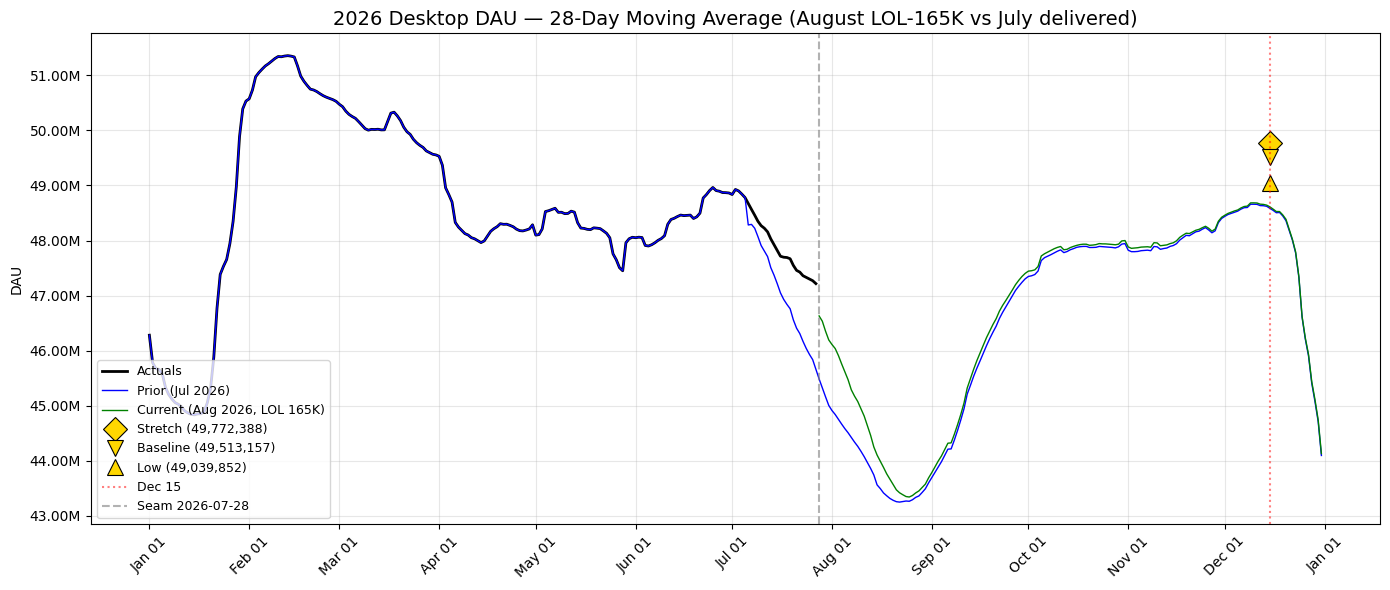

In [7]:
# [plot-desktop]
# Stakeholder Dec-15 benchmarks. These are the ASPIRATIONAL low/baseline/stretch markers originally
# set for the June cycle and reused unchanged in July; they are NOT August targets and no August
# target has been set. Kept only so the vertical scale is comparable with the June/July plots.
STAKEHOLDER_DESKTOP_LOW = 49_039_852
STAKEHOLDER_DESKTOP_BASELINE = 49_513_157
STAKEHOLDER_DESKTOP_STRETCH = 49_772_388


def render_desktop_plot(*, show_prior: bool, title: str, savename: str):
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(clip_display(desktop_actual_ma), label="Actuals", color="black", linewidth=2)
    if show_prior:
        ax.plot(clip_display(prev_desktop_ma), label="Prior (Jul 2026)", color="blue", linewidth=1)
    ax.plot(clip_forecast_only(desktop_ma), label="Current (Aug 2026, LOL 165K)",
            color="green", linewidth=1)
    for value, marker, label in [
        (STAKEHOLDER_DESKTOP_STRETCH, "D", "Stretch"),
        (STAKEHOLDER_DESKTOP_BASELINE, "v", "Baseline"),
        (STAKEHOLDER_DESKTOP_LOW, "^", "Low"),
    ]:
        ax.plot(MEASUREMENT_DATE, value, marker=marker, color="gold",
                markersize=12, markeredgecolor="black", markeredgewidth=0.8,
                linestyle="None", label=f"{label} ({value:,})")
    ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
    ax.axvline(FORECAST_START, color="grey", linestyle="--", alpha=0.6,
               label=f"Seam {FORECAST_START.date()}")
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("DAU")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc="lower left", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    out = f"{PLOTS_DIR}/{savename}"
    fig.savefig(out, dpi=130)
    print(f"saved: {out}")
    plt.show()


render_desktop_plot(
    show_prior=True,
    title="2026 Desktop DAU — 28-Day Moving Average (August LOL-165K vs July delivered)",
    savename="desktop_lol165_vs_july.png")


saved: data-official/2026-08/plots/desktop_lol165_only.png


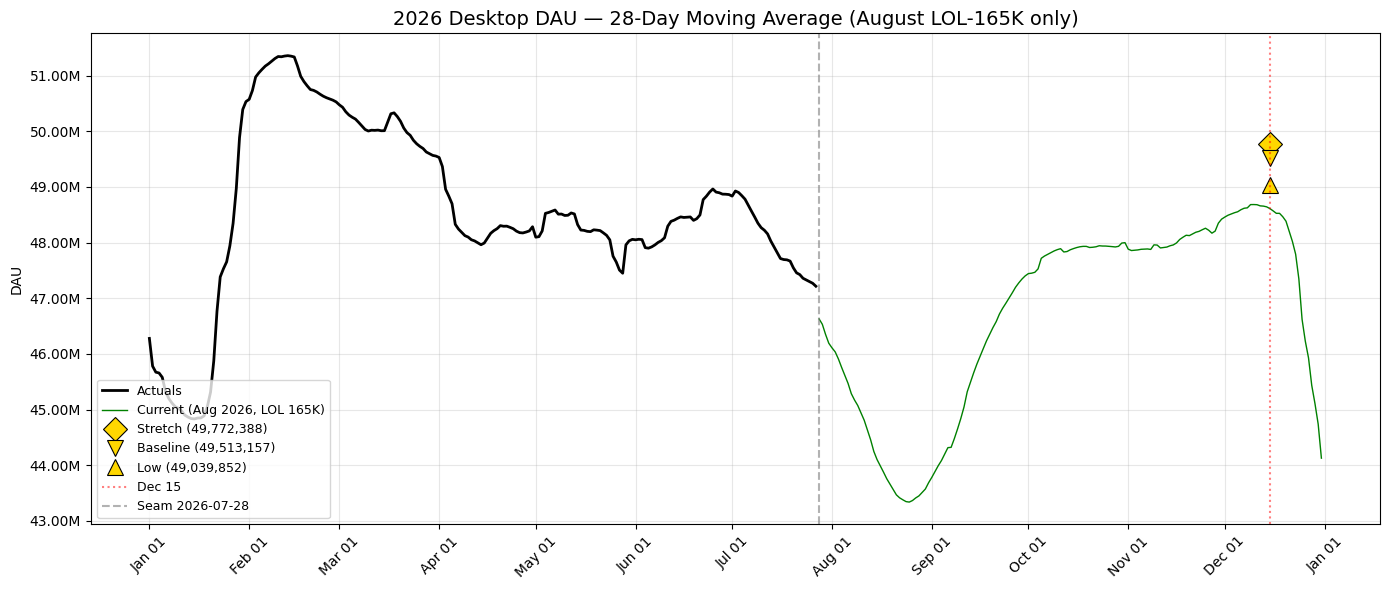

In [8]:
# [plot-desktop-current-only]
render_desktop_plot(
    show_prior=False,
    title="2026 Desktop DAU — 28-Day Moving Average (August LOL-165K only)",
    savename="desktop_lol165_only.png")


In [9]:
# [desktop-dec15]
# Hardcoded historical measurements, all post-headwind Dec-15 28d-MA. These are MEASUREMENTS of earlier
# builds, not recomputable from this notebook's state, so they are pinned as literals:
#   JULY_DELIVERED     -- data-official/2026-07/_index.md. The prior curve rebuilt below must reproduce
#                         it; a mismatch means the N-1 line is not what was delivered.
#   AUG_125K_OLD_HW    -- the first August build: 125K LOL curve, headwind -1,345,000, this anchor and
#                         data. Superseded in place; number preserved in git commit 140412e.
#   LOL_CAP_EFFECT     -- measured when the LOL ceiling went 125K -> 165K (commit eb69b41), holding the
#                         headwind at -1,345,000. Because the headwind is additive at the display layer,
#                         this pre/post-headwind figure is the same number either way.
JULY_DELIVERED_DESKTOP_DEC15 = 48_585_483
AUG_125K_OLD_HW = 48_520_714
LOL_CAP_EFFECT = 41_081

desktop_series = {
    "Actuals": desktop_actual_ma,
    "Prior (Jul 2026 delivered)": prev_desktop_ma,
    "Current (Aug 2026, LOL 165K)": desktop_ma,
}

header = f"{'Series':<32s} {'Dec 15 28-day MA':>18s}"
print(header)
print("-" * len(header))
for name, s in desktop_series.items():
    val = s.get(MEASUREMENT_DATE, np.nan)
    val_str = f"{val:,.0f}" if pd.notna(val) else "N/A"
    print(f"{name:<32s} {val_str:>18s}")

prior_recomputed = prev_desktop_ma.get(MEASUREMENT_DATE, np.nan)
drift = prior_recomputed - JULY_DELIVERED_DESKTOP_DEC15
print(f"\nPrior-curve reproduction check: recomputed {prior_recomputed:,.0f} vs "
      f"delivered {JULY_DELIVERED_DESKTOP_DEC15:,.0f} (drift {drift:+,.0f})")
assert abs(drift) < 1000, (
    f"July's delivered desktop Dec-15 does not reproduce (drift {drift:+,.0f}). The prior comparison "
    f"line is not the delivered July forecast -- investigate before quoting any delta."
)

# --- Attribution ledger -------------------------------------------------------------------------
# Three independent changes separate July's delivered number from the current one. The headwind step is
# read from the two spec dirs rather than hardcoded, so editing headwind.json updates this automatically.
current = desktop_ma.get(MEASUREMENT_DATE, np.nan)
headwind_now = net_adjustments["desktop"].get(MEASUREMENT_DATE, np.nan)
headwind_july = prev_net_adjustments["desktop"].get(MEASUREMENT_DATE, np.nan)
headwind_step = headwind_now - headwind_july

data_refresh_effect = AUG_125K_OLD_HW - JULY_DELIVERED_DESKTOP_DEC15

ledger = [
    ("July delivered (125K LOL, 07-06 anchor, hw -1,345,000)", None, JULY_DELIVERED_DESKTOP_DEC15),
    ("+ data refresh to the 07-28 anchor", data_refresh_effect, AUG_125K_OLD_HW),
    ("+ LOL ceiling 125K -> 165K", LOL_CAP_EFFECT, AUG_125K_OLD_HW + LOL_CAP_EFFECT),
    (f"+ Win10 headwind {headwind_july:,.0f} -> {headwind_now:,.0f}", headwind_step,
     AUG_125K_OLD_HW + LOL_CAP_EFFECT + headwind_step),
]

print(f"\nDec-15 desktop 28d-MA attribution ledger (all post-headwind):")
w = max(len(r[0]) for r in ledger)
for label, step, running in ledger:
    step_str = f"{step:+,.0f}" if step is not None else ""
    print(f"  {label:<{w}}  {step_str:>10}  ->  {running:>12,.0f}")

ledger_total = ledger[-1][2]
residual = current - ledger_total
print(f"\n  {'measured current build':<{w}}  {'':>10}  ->  {current:>12,.0f}")
print(f"  {'ledger residual':<{w}}  {'':>10}      {residual:>12,.0f}")

# The ledger must close exactly: the headwind is additive at the display layer, so
# (125K build) + (LOL cap effect) + (headwind step) is algebraically the current build. A non-trivial
# residual means one of the pinned constants is stale or the desktop parquet is not the one these
# measurements describe. Tolerance is 10 DAU, covering only the rounding in the pinned literals.
assert abs(residual) < 10, (
    f"Attribution ledger does not close (residual {residual:+,.0f}). One of AUG_125K_OLD_HW / "
    f"LOL_CAP_EFFECT is stale, or the desktop forecast was rebuilt with a different curve. Do not "
    f"quote the attribution until this is resolved."
)

# The LOL curve is +40,000/day higher at every forecast date. A realised effect of exactly +40,000
# would mean the curve was added to the forecast without being subtracted from training -- a broken
# bidirectional overlay rather than a good result.
CURVE_DELTA_AT_DEC15 = 40_000
assert abs(LOL_CAP_EFFECT - CURVE_DELTA_AT_DEC15) > 1, (
    f"LOL effect equals the raw curve delta exactly ({LOL_CAP_EFFECT:+,.0f}); the bidirectional "
    f"subtract-from-training leg appears not to have run."
)
print(f"\nLOL pass-through: curve +{CURVE_DELTA_AT_DEC15:,}/day at Dec-15, realised {LOL_CAP_EFFECT:+,} "
      f"({(LOL_CAP_EFFECT / CURVE_DELTA_AT_DEC15 - 1) * 100:+.0f}% vs the raw curve change)")
print(f"Net vs July delivered: {current - JULY_DELIVERED_DESKTOP_DEC15:+,.0f} DAU "
      f"({(current / JULY_DELIVERED_DESKTOP_DEC15 - 1) * 100:+.2f}%)")


Series                             Dec 15 28-day MA
---------------------------------------------------
Actuals                                         N/A
Prior (Jul 2026 delivered)               48,585,483
Current (Aug 2026, LOL 165K)             48,611,795

Prior-curve reproduction check: recomputed 48,585,483 vs delivered 48,585,483 (drift +0)

Dec-15 desktop 28d-MA attribution ledger (all post-headwind):
  July delivered (125K LOL, 07-06 anchor, hw -1,345,000)              ->    48,585,483
  + data refresh to the 07-28 anchor                         -64,769  ->    48,520,714
  + LOL ceiling 125K -> 165K                                 +41,081  ->    48,561,795
  + Win10 headwind -1,345,000 -> -1,295,000                  +50,000  ->    48,611,795

  measured current build                                              ->    48,611,795
  ledger residual                                                                   -0

LOL pass-through: curve +40,000/day at Dec-15, realised +41,081

saved: data-official/2026-08/plots/mobile_august_vs_july.png


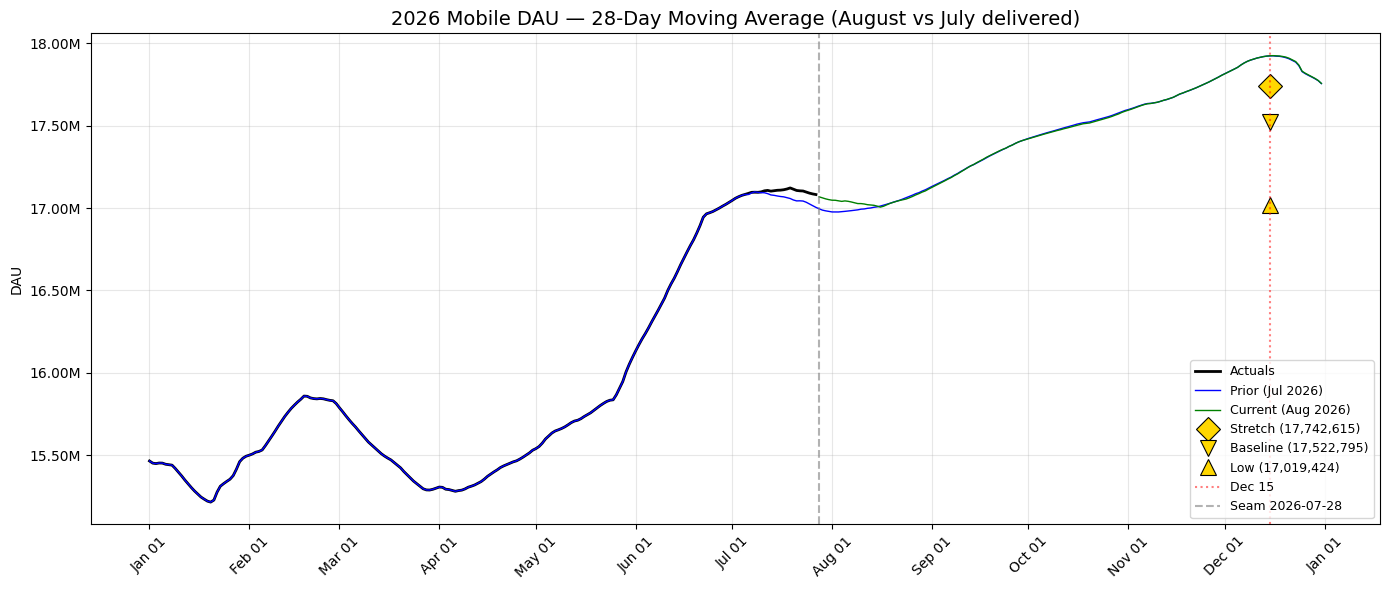

In [10]:
# [plot-mobile]
# Stakeholder Dec-15 mobile benchmarks. As with desktop, these are the June-cycle aspirational
# markers reused in July, NOT August targets. Kept for scale comparability only.
STAKEHOLDER_MOBILE_LOW = 17_019_424
STAKEHOLDER_MOBILE_BASELINE = 17_522_795
STAKEHOLDER_MOBILE_STRETCH = 17_742_615


def render_mobile_plot(*, show_prior: bool, title: str, savename: str):
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(clip_display(mobile_actual_ma), label="Actuals", color="black", linewidth=2)
    if show_prior:
        ax.plot(clip_display(prev_mobile_ma), label="Prior (Jul 2026)", color="blue", linewidth=1)
    # Mobile is UNCHANGED by the LOL rebuild -- `l` is desktop-only, so this is the same mobile run as
    # the 125K baseline. Any movement vs July is the data refresh alone.
    ax.plot(clip_forecast_only(mobile_ma, MOBILE_FORECAST_START),
            label="Current (Aug 2026)", color="green", linewidth=1)
    for value, marker, label in [
        (STAKEHOLDER_MOBILE_STRETCH, "D", "Stretch"),
        (STAKEHOLDER_MOBILE_BASELINE, "v", "Baseline"),
        (STAKEHOLDER_MOBILE_LOW, "^", "Low"),
    ]:
        ax.plot(MEASUREMENT_DATE, value, marker=marker, color="gold",
                markersize=12, markeredgecolor="black", markeredgewidth=0.8,
                linestyle="None", label=f"{label} ({value:,})")
    ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
    ax.axvline(MOBILE_FORECAST_START, color="grey", linestyle="--", alpha=0.6,
               label=f"Seam {MOBILE_FORECAST_START.date()}")
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("DAU")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc="lower right", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    out = f"{PLOTS_DIR}/{savename}"
    fig.savefig(out, dpi=130)
    print(f"saved: {out}")
    plt.show()


render_mobile_plot(
    show_prior=True,
    title="2026 Mobile DAU — 28-Day Moving Average (August vs July delivered)",
    savename="mobile_august_vs_july.png")


saved: data-official/2026-08/plots/mobile_august_only.png


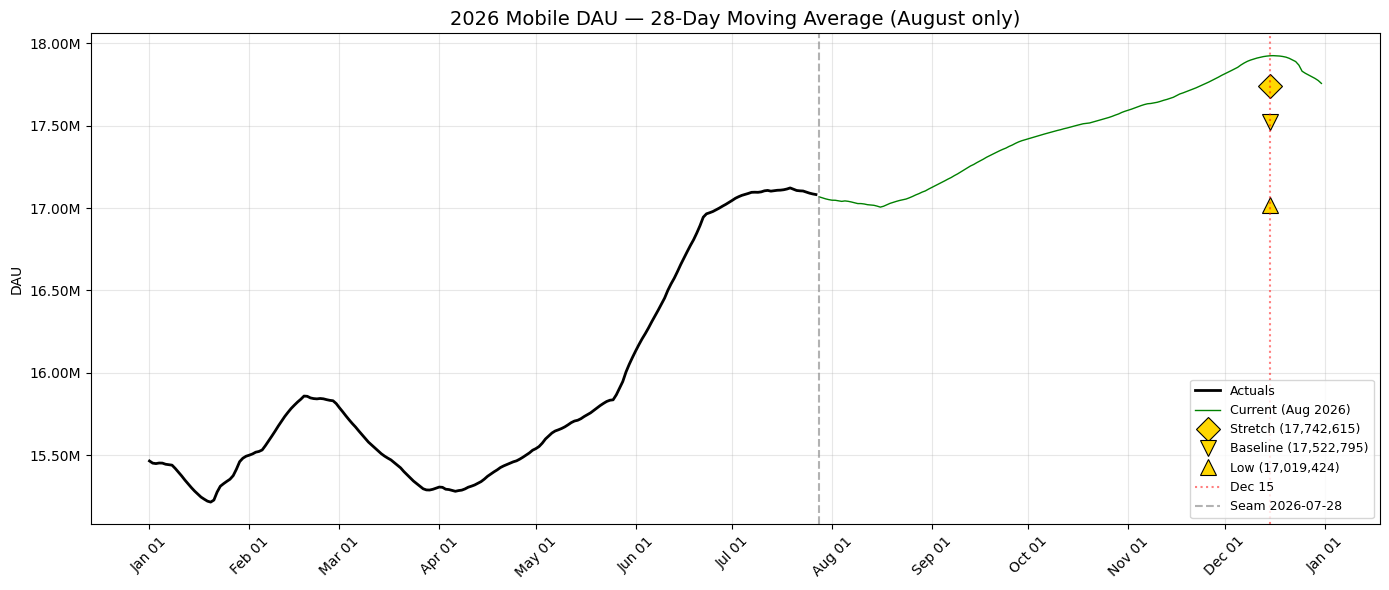

In [11]:
# [plot-mobile-current-only]
render_mobile_plot(
    show_prior=False,
    title="2026 Mobile DAU — 28-Day Moving Average (August only)",
    savename="mobile_august_only.png")


saved: data-official/2026-08/plots/mobile_ex_iran_august_vs_july.png


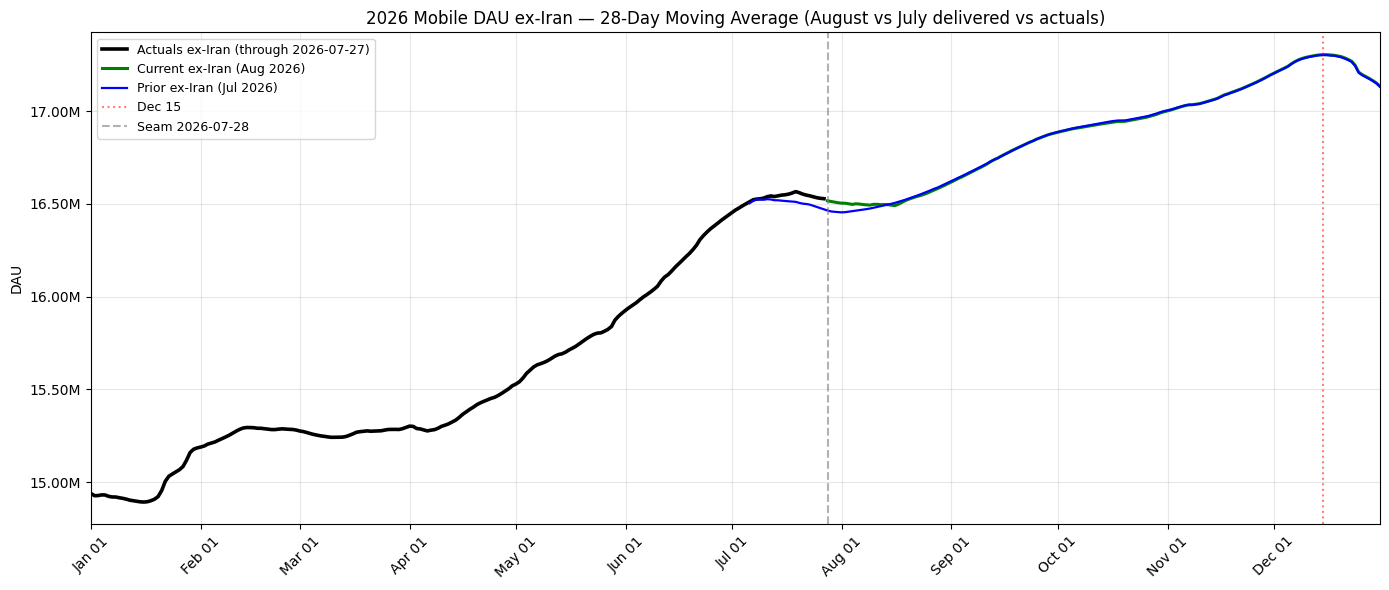


Dec-15 ex-Iran 28d MA:  August 17,303,955  |  July 17,302,425  |  delta +1,530


In [12]:
# [plot-mobile-ex-iran]
# ALL-MOBILE EXCLUDING Iran (28d MA): August vs July delivered vs actuals.
# Mobile is unaffected by the desktop-only LOL rebuild; this is the data-refresh comparison.
# Removing Iran strips the post-shutdown reconnection bounce so the underlying trajectories are
# directly comparable. Iran is still in the headline (incl-Iran) curves above.
#
# NOTE ON METHOD: July's notebook took its ex-Iran PRIOR line from a precomputed column in
# june_canonical_curves.csv. July's own canonical CSV has no ex-Iran columns, so both curves here are
# derived from their respective parquets (ALL minus IR), each with its own headwind and its own seam.
# That is self-consistent and avoids depending on a column that does not exist.


def ex_iran_ma(parquet_path, seam, require_state, adjustments):
    """World-minus-Iran mobile DAU as a seam-smoothed, headwind-adjusted 28d MA.

    Returns (forecast_ma, actual_ma). The actual leg uses training rows only and the plain
    trailing MA; the forecast leg uses display_ma plus the mobile headwind from `adjustments`.
    """
    df, _ = load_forecast(parquet_path, require_state=require_state)
    df["target_date"] = pd.to_datetime(df["target_date"])

    def series(country, data_type=None):
        mask = ((df.data_source == "glean_mobile") & (df.country == country)
                & (df.app_name == "ALL MOBILE") & (df.segment == "{}"))
        rows = df.loc[mask]
        if data_type is not None:
            rows = rows[rows.data_type == data_type]
        return rows.set_index("target_date").sort_index()["dau"]

    ex_ir = series("ALL").subtract(series("IR"), fill_value=0.0)
    forecast_ma = apply_net_adjustment(
        display_ma(ex_ir.index.to_series(), ex_ir, seam),
        adjustments, "mobile", forecast_start=seam)

    act = series("ALL", "training").subtract(series("IR", "training"), fill_value=0.0)
    return forecast_ma, daily_to_28ma(act.index.to_series(), act)


aug_exir_ma, act_exir_ma = ex_iran_ma(
    MOBILE_FORECAST_PATH, MOBILE_FORECAST_START, ["m"], net_adjustments)
jul_exir_ma, _ = ex_iran_ma(
    PREV_FORECAST_MOBILE_PATH, PREV_FORECAST_START, ["m"], prev_net_adjustments)

SEAM = MOBILE_FORECAST_START - pd.Timedelta(days=1)   # 2026-07-27, last actual day

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(act_exir_ma.loc[DISPLAY_START:SEAM].index, act_exir_ma.loc[DISPLAY_START:SEAM],
        color="black", linewidth=2.6, label=f"Actuals ex-Iran (through {SEAM.date()})")
ax.plot(aug_exir_ma.loc[MOBILE_FORECAST_START:DISPLAY_END].index,
        aug_exir_ma.loc[MOBILE_FORECAST_START:DISPLAY_END],
        color="green", linewidth=2.2, label="Current ex-Iran (Aug 2026)")
ax.plot(jul_exir_ma.loc[PREV_FORECAST_START:DISPLAY_END].index,
        jul_exir_ma.loc[PREV_FORECAST_START:DISPLAY_END],
        color="blue", linewidth=1.6, label="Prior ex-Iran (Jul 2026)")
ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
ax.axvline(MOBILE_FORECAST_START, color="grey", linestyle="--", alpha=0.6,
           label=f"Seam {MOBILE_FORECAST_START.date()}")
ax.set_title("2026 Mobile DAU ex-Iran — 28-Day Moving Average "
             "(August vs July delivered vs actuals)")
ax.set_ylabel("DAU")
ax.set_xlim(DISPLAY_START, DISPLAY_END)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
out = f"{PLOTS_DIR}/mobile_ex_iran_august_vs_july.png"
fig.savefig(out, dpi=130)
print(f"saved: {out}")
plt.show()

print(f"\nDec-15 ex-Iran 28d MA:  August {aug_exir_ma.get(MEASUREMENT_DATE, np.nan):,.0f}  |  "
      f"July {jul_exir_ma.get(MEASUREMENT_DATE, np.nan):,.0f}  |  "
      f"delta {aug_exir_ma.get(MEASUREMENT_DATE, np.nan) - jul_exir_ma.get(MEASUREMENT_DATE, np.nan):+,.0f}")


In [13]:
# [mobile-dec15]
# July's DELIVERED mobile Dec-15 28d-MA, from data-official/2026-07/_index.md. Same reproduction
# check as desktop: if the prior curve does not rebuild to the delivered number, the deltas are junk.
#
# Mobile is UNCHANGED by the LOL rebuild -- `l` applies to legacy_desktop only, so this is the same
# mobile parquet the 125K baseline used. Its Dec-15 was 17,924,607; it should still be exactly that.
JULY_DELIVERED_MOBILE_DEC15 = 17_923_869
AUG_BASELINE_MOBILE_DEC15 = 17_924_607

mobile_series = {
    "Actuals": mobile_actual_ma,
    "Prior (Jul 2026 delivered)": prev_mobile_ma,
    "Current (Aug 2026)": mobile_ma,
}

header = f"{'Series':<30s} {'Dec 15 28-day MA':>18s}"
print(header)
print("-" * len(header))
for name, s in mobile_series.items():
    val = s.get(MEASUREMENT_DATE, np.nan)
    val_str = f"{val:,.0f}" if pd.notna(val) else "N/A"
    print(f"{name:<30s} {val_str:>18s}")

prior_recomputed = prev_mobile_ma.get(MEASUREMENT_DATE, np.nan)
drift = prior_recomputed - JULY_DELIVERED_MOBILE_DEC15
print(f"\nPrior-curve reproduction check: recomputed {prior_recomputed:,.0f} vs "
      f"delivered {JULY_DELIVERED_MOBILE_DEC15:,.0f} (drift {drift:+,.0f})")
assert abs(drift) < 1000, (
    f"July's delivered mobile Dec-15 does not reproduce (drift {drift:+,.0f}). "
    f"Investigate before quoting any August-vs-July delta."
)

current = mobile_ma.get(MEASUREMENT_DATE, np.nan)
print(f"\nAugust vs July delivered: {current - JULY_DELIVERED_MOBILE_DEC15:+,.0f} DAU "
      f"({(current / JULY_DELIVERED_MOBILE_DEC15 - 1) * 100:+.2f}%)")

# Mobile must be untouched by a desktop-only overlay change. If this drifts, either the mobile parquet
# was regenerated when it should not have been, or `l` is leaking outside legacy_desktop.
mobile_drift = current - AUG_BASELINE_MOBILE_DEC15
print(f"vs the 125K-baseline mobile run:  {mobile_drift:+,.0f} DAU (expected exactly 0 -- `l` is desktop-only)")
assert abs(mobile_drift) < 1, (
    f"Mobile Dec-15 moved by {mobile_drift:+,.0f} after a DESKTOP-only overlay change. Either the "
    f"mobile forecast was rebuilt unintentionally or the `l` overlay is leaking beyond legacy_desktop."
)


Series                           Dec 15 28-day MA
-------------------------------------------------
Actuals                                       N/A
Prior (Jul 2026 delivered)             17,923,869
Current (Aug 2026)                     17,924,607

Prior-curve reproduction check: recomputed 17,923,869 vs delivered 17,923,869 (drift -0)

August vs July delivered: +738 DAU (+0.00%)
vs the 125K-baseline mobile run:  +0 DAU (expected exactly 0 -- `l` is desktop-only)


In [14]:
# [dec15-summary]
# Headline table: August baseline vs July delivered at the Dec-15 2026 measurement date, 28-day MA.
# ALL = Desktop + Mobile (the two platforms are disjoint populations, so a plain sum is correct).
rows = []
for label, current, prior in [
    ("Desktop", desktop_ma.get(MEASUREMENT_DATE, np.nan), prev_desktop_ma.get(MEASUREMENT_DATE, np.nan)),
    ("Mobile", mobile_ma.get(MEASUREMENT_DATE, np.nan), prev_mobile_ma.get(MEASUREMENT_DATE, np.nan)),
]:
    rows.append((label, current, prior))
rows.append((
    "ALL",
    sum(r[1] for r in rows),
    sum(r[2] for r in rows),
))

label_w = max(len(r[0]) for r in rows)
col_w = 20

print("Dec 15, 2026 — 28-day moving average")
print("(August = July's locked params, data through 2026-07-27, LOL ceiling 125K -> 165K,")
print(" Win10 headwind desktop anchor -1,345,000 -> -1,295,000. The `o` and `m` overlays are")
print(" still unchanged stale carry-forwards from July.)")
print()
header = (f"{'Series':<{label_w}}  {'Aug (LOL 165K)':>{col_w}}  {'Jul delivered':>{col_w}}  "
          f"{'Delta':>{col_w}}  {'Delta %':>9}")
print(header)
print("-" * len(header))
for label, current, prior in rows:
    print(f"{label:<{label_w}}  {current:>{col_w},.0f}  {prior:>{col_w},.0f}  "
          f"{current - prior:>{col_w},.0f}  {(current / prior - 1) * 100:>8.2f}%")

# Also report the near-horizon summer trough, the KPI the aug22-retune search was built around.
# Reported here for visibility only -- no target is being asserted and nothing was tuned to it.
TROUGH_DATE = pd.Timestamp("2026-08-22")
print(f"\nNear-horizon check — {TROUGH_DATE.date()} summer trough (28d MA, post-headwind):")
for label, s in [("Desktop", desktop_ma), ("Mobile", mobile_ma)]:
    print(f"  {label:<8s} {s.get(TROUGH_DATE, np.nan):,.0f}")
print(f"  {'ALL':<8s} {desktop_ma.get(TROUGH_DATE, np.nan) + mobile_ma.get(TROUGH_DATE, np.nan):,.0f}")


Dec 15, 2026 — 28-day moving average
(August = July's locked params, data through 2026-07-27, LOL ceiling 125K -> 165K,
 Win10 headwind desktop anchor -1,345,000 -> -1,295,000. The `o` and `m` overlays are
 still unchanged stale carry-forwards from July.)

Series         Aug (LOL 165K)         Jul delivered                 Delta    Delta %
------------------------------------------------------------------------------------
Desktop            48,611,795            48,585,483                26,311      0.05%
Mobile             17,924,607            17,923,869                   738      0.00%
ALL                66,536,402            66,509,352                27,050      0.04%

Near-horizon check — 2026-08-22 summer trough (28d MA, post-headwind):
  Desktop  43,415,259
  Mobile   17,046,467
  ALL      60,461,726


## Caveats — read before quoting any number above

This is **not a delivered forecast**. `l` has been refreshed and the headwind anchor attenuated; `o` and
`m` are still stale carry-forwards from July.

### Overlay freshness

| overlay | state | detail |
|---|---|---|
| `l` launch-on-login | **REFRESHED 2026-07-29** | 165,000 ceiling, reached 2026-07-06. Measured to 2026-06-23, extrapolated after. The extrapolation is unavoidable, not laziness — see below. |
| `o` MozillaOnline | **STALE (~5 weeks)** | Brad's curve, built from data through late June. Deliberately conservative: July recorded actuals already running **ahead** of the ramp. Under-subtraction leaves migration signal in the trend. |
| `m` marketing lift | **STALE (~4 weeks)** | June-anchored Fenix paid curve. Whether it over- or under-states depends on how July's actual paid delivery tracked the marketing outlook — unknown until re-measured. |

For the two stale overlays the bidirectional appliers subtract the curve from training rows before
mozaic, so for the 2026-06-29 → 2026-07-27 rows what gets subtracted is the curve's **modelled** value,
not a measured one. Where reality diverged, Prophet absorbs the residual into trend.

### The LOL measurement window is closed permanently

Everything in the `l` curve after **2026-06-23** is extrapolation by construction. Contamination begins
2026-06-24: the holdback control group received the feature, so the counterfactual is gone. No fresh
telemetry can extend the clean window — querying recent data shows the excess "collapsing," which is an
artifact of the control being treated, not a decay. **Do not attempt to re-measure this.**

The 165,000 ceiling is a judgement, not a measurement. It sits between the previous conservative 125,000
and an independent convolution model of the same effect (`~/work/launch-on-login/dau_model_convolution.ipynb`)
that lands near 220,000/day — so it carries a standing haircut of roughly 55K/day. The measured effect
had *not* plateaued at the cutoff (still rising ~19K/wk) and is stopped dead anyway: growth that cannot
be validated is not extrapolated forward.

The curve is **not strictly monotone** — six small downward steps inside the measured window (largest
−1,207, ≈1% of level) are day-of-week residue in the 7d-MA, four of which were already present in the
125K curve. That is smoothing noise, not a modelled drop-off; it was left measurement-faithful rather
than smoothed. From 2026-06-24 onward the curve is strictly non-decreasing.

### The Win10 headwind anchor is a judgement, and it has now moved twice

Desktop is at **−1,295,000** at the Dec-15 anchor, attenuated +50,000 from July's −1,345,000 on
2026-07-29. Mobile is unchanged at −27,162.

The reasoning is the same each cycle: `adj-h` carries the part of the Win10 migration decline that
Prophet has *not* learned from data, so as the decline shows up in actuals the exogenous anchor should
shrink or it double-counts. June concluded this, July acted on it (−1,420,000 → −1,370,000 → −1,345,000),
and this cycle continues it. **But note the sequence** — three successive attenuations, each justified
the same way, each raising the reported number:

| cycle | desktop anchor | step |
|---|--:|--:|
| June delivered | −1,420,000 | — |
| July, first pass | −1,370,000 | +50,000 |
| July delivered | −1,345,000 | +25,000 |
| **August current** | **−1,295,000** | **+50,000** |

None of these steps is measured against a held-out estimate of how much of the Win10 decline Prophet has
actually absorbed — they are calibrated judgements. That is defensible once; it deserves scrutiny as a
run. If a cycle ever needs the headwind to attenuate in order to hit a target, that is the failure mode
to watch for. Worth a validation pass against realised Win10-cohort DAU before the next step.

Because `h` is applied at the display layer, this change moves the reported number **+50,000 exactly**
at Dec-15 with no interaction with the model — the desktop parquet is untouched.

### No target has been set for August

The gold low/baseline/stretch markers in the plots are the **June-cycle** aspirational benchmarks,
reused unchanged in July and again here purely so the vertical scale matches the earlier charts. They
are not August targets.

### Separately open (not acted on here)

- **Summer-trough shortfall.** `research/param-scans/aug22-retune/` established that no exposed
  parameter combination lifts the August trough to target while holding Dec-15 (best sampled point
  0.385M short). Its recommendation is a new bidirectional summer-trough overlay tapering to ~0 by
  Nov/Dec. That is a **recommendation awaiting a go/no-go**, and nothing here implements it. The Aug-22
  trough is printed above for visibility only — nothing was tuned toward it.
- **The 2026-06 dependency.** This notebook still imports `display_ma` from
  `data-official/2026-06/export_canonical_curves.py`, and the `m` overlay chain still reaches into June.
  Flagged for the September roll-forward; see `data-official/_index.md`.
- **The `m` curve ends 2026-12-31** and the applier fills later dates with 0.0, so mobile marketing lift
  drops to zero across the 2027 horizon. Pre-existing in July, harmless for the Dec-15 2026 KPI, wrong
  if anyone reads 2027 out of this parquet.
